In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
air_quality_data = pd.read_csv('../data/processed_air_quality_data.csv')
air_quality_data.head(15)

,O3,PM25,district,CO,NO2,datetime,SO2,PM10
0,47.5,42.0,南山区,0.6500,29.5,2020-01-01,4.5,75.5
1,52.5,38.5,坪山区,0.9530,20.0,2020-01-01,8.5,71.0
2,68.5,34.0,大鹏新区,0.7500,11.5,2020-01-01,5.5,49.5
3,53.0,49.0,宝安区,0.9000,41.0,2020-01-01,6.0,88.0
4,57.0,41.0,深圳市,0.7000,25.0,2020-01-01,6.0,66.0
5,60.0,36.0,盐田区,0.7000,26.5,2020-01-01,6.5,61.0
6,67.0,46.0,福田区,0.8000,20.0,2020-01-01,6.0,72.0
7,64.0,47.0,罗湖区,0.8000,29.0,2020-01-01,6.0,64.0
8,39.0,44.0,龙华区,0.5000,16.0,2020-01-01,6.0,72.0
9,50.0,45.0,龙岗区,0.8000,33.0,2020-01-01,6.0,62.0


In [9]:
pm_series=air_quality_data[air_quality_data['district']=='深圳市'][['datetime', 'PM25']].copy()

In [11]:
pm_series.reset_index(drop=True, inplace=True)
pm_series.head()

,datetime,PM25
0,2020-01-01,41.0
1,2020-01-02,33.0
2,2020-01-03,44.0
3,2020-01-04,48.0
4,2020-01-05,24.0


In [21]:
from statsmodels.tsa.seasonal import STL
df = pm_series.copy()
# 转换为 datetime 类型
df["datetime"] = pd.to_datetime(df["datetime"])

# 排序
df = df.sort_values("datetime")

# 设置为索引
df = df.set_index("datetime")
y = df["PM25"].interpolate("time").ffill().bfill()
print("时间范围：", y.index.min(), "→", y.index.max())
print("样本量：", len(y))
print("缺失比例：", y.isna().mean())

时间范围： 2020-01-01 00:00:00 → 2025-12-31 00:00:00
样本量： 2196
缺失比例： 0.0


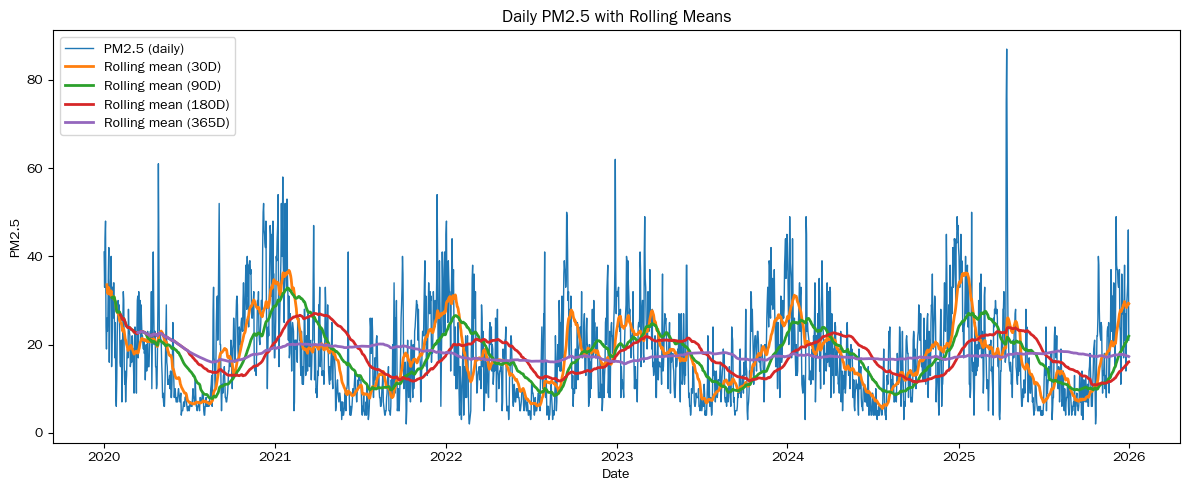

In [22]:
#  Rolling 平滑曲线：30/90/180/365
windows = [30, 90, 180, 365]
roll = {w: y.rolling(window=w, min_periods=max(7, w//5)).mean() for w in windows}

plt.figure(figsize=(12, 5))
plt.plot(y.index, y.values, linewidth=1, label="PM2.5 (daily)")
for w in windows:
    plt.plot(roll[w].index, roll[w].values, linewidth=2, label=f"Rolling mean ({w}D)")
plt.title("Daily PM2.5 with Rolling Means")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

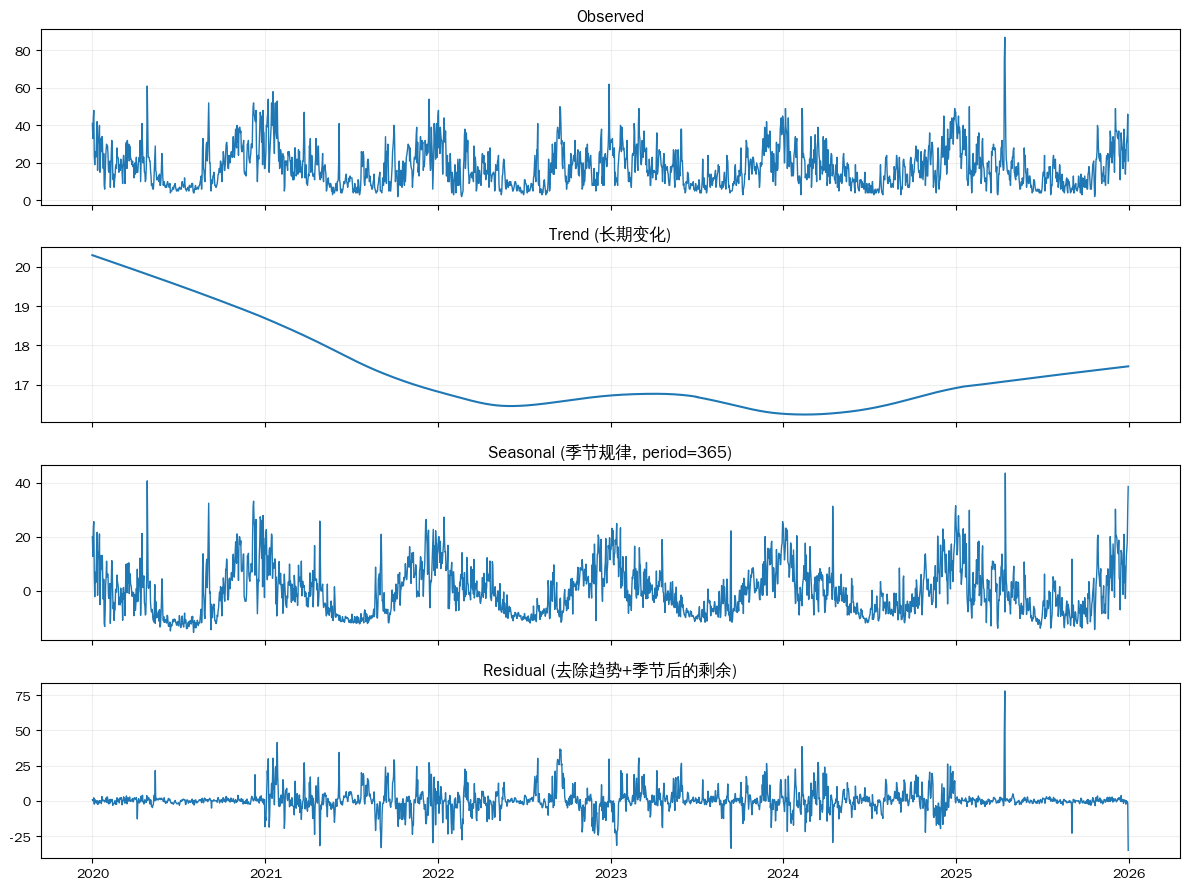

            observed      trend   seasonal     resid
datetime                                            
2020-01-01      41.0  20.295242  20.025324  0.679434
2020-01-02      33.0  20.291112  12.698554  0.010334
2020-01-03      44.0  20.286981  23.321521  0.391498
2020-01-04      48.0  20.282849  25.593326  2.123825
2020-01-05      24.0  20.278716   6.080033 -2.358749

Missing ratio: observed    0.0
trend       0.0
seasonal    0.0
resid       0.0
dtype: float64


In [23]:
#STL 分解：period=365
stl = STL(y, period=365, robust=True).fit()

stl_df = pd.DataFrame({
    "observed": y,
    "trend": stl.trend,
    "seasonal": stl.seasonal,
    "resid": stl.resid
})

# STL 组件绘图
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(stl_df.index, stl_df["observed"], linewidth=1)
axes[0].set_title("Observed")

axes[1].plot(stl_df.index, stl_df["trend"], linewidth=1.5)
axes[1].set_title("Trend (长期变化)")

axes[2].plot(stl_df.index, stl_df["seasonal"], linewidth=1)
axes[2].set_title("Seasonal (季节规律, period=365)")

axes[3].plot(stl_df.index, stl_df["resid"], linewidth=1)
axes[3].set_title("Residual (去除趋势+季节后的剩余)")

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(stl_df.head())
print("\nMissing ratio:", stl_df.isna().mean())

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

# ===== 取序列 =====
df = pm_series.copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").set_index("datetime")

# STL residual（假设你已经算过 stl_df）
resid = stl_df["resid"]

# ===== 构造序列集合 =====
series_dict = {
    "Original": y,
    "Log": np.log(y + 1),
    "STL Resid": resid,
    "Diff(1)": y.diff().dropna(),
    "Seasonal Diff(365)": y.diff(365).dropna()
}

# ===== 检验函数 =====
def test_stationarity(series):
    result = {}
    
    # ADF
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC')
    
    # KPSS
    kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags="auto")
    
    result["ADF_stat"] = adf_stat
    result["ADF_p"] = adf_p
    result["KPSS_stat"] = kpss_stat
    result["KPSS_p"] = kpss_p
    
    return result

# ===== 批量运行 =====
results = {}

for name, s in series_dict.items():
    s_clean = s.dropna()
    results[name] = test_stationarity(s_clean)

results_df = pd.DataFrame(results).T
results_df

/tmp/ipykernel_15411/4268422912.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags="auto")
/tmp/ipykernel_15411/4268422912.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags="auto")
/tmp/ipykernel_15411/4268422912.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags="auto")
/tmp/ipykernel_15411/4268422912.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is

,ADF_stat,ADF_p,KPSS_stat,KPSS_p
Original,-6.719586,3.510677e-09,0.105657,0.1
Log,-5.978710,1.860612e-07,0.092415,0.1
STL Resid,-14.353288,1.013229e-26,0.037653,0.1
Diff(1),-14.088153,2.751831e-26,0.061838,0.1
Seasonal Diff(365),-8.802275,2.096633e-14,0.139014,0.1


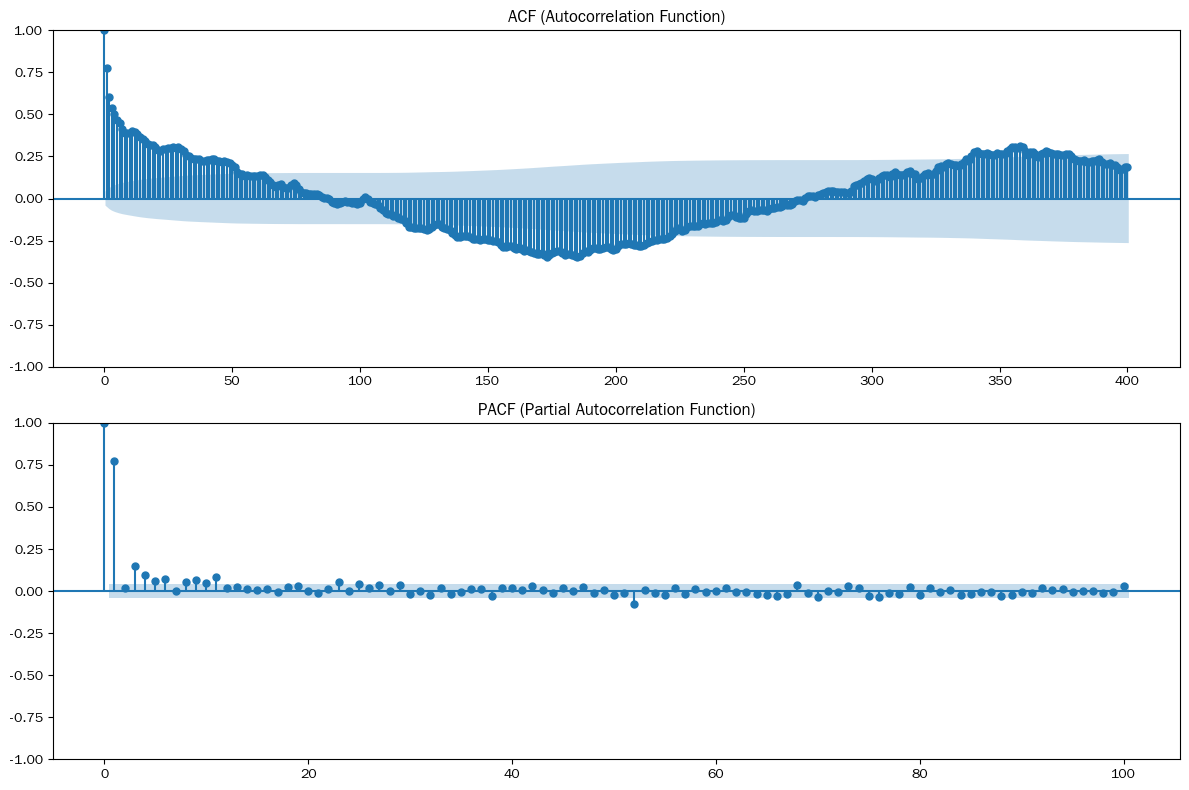

In [27]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = pm_series.copy()
y["datetime"] = pd.to_datetime(y["datetime"])
y = y.sort_values("datetime").set_index("datetime")["PM25"]
#y = y.asfreq("D").interpolate("time").ffill().bfill()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y, lags=400, ax=axes[0])
axes[0].set_title("ACF (Autocorrelation Function)")

plot_pacf(y, lags=100, ax=axes[1], method="ywm")
axes[1].set_title("PACF (Partial Autocorrelation Function)")

plt.tight_layout()
plt.show()